IRIS DATASET
   SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa

Information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Summary
       SepalLength  SepalWidth  PetalLength  PetalWidth
count   150.000000  150.000000   150.000000  150.000000
mean      5.843333    3

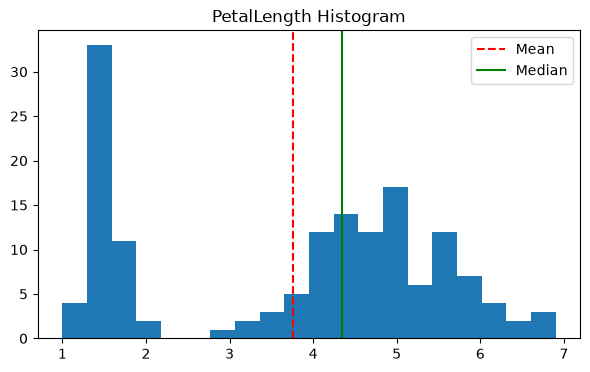

C:\Users\anits-csm\AppData\Local\Temp\ipykernel_20088\4294594933.py:60: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data, vert=False)


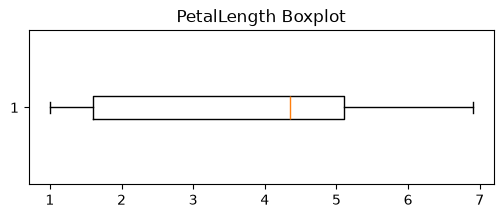


Statistics After Removing Outliers
Mean = 3.758666666666666
Median = 4.35
Variance = 3.113179418344519
Standard Deviation = 1.7644204199522626


TITANIC DATASET
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  

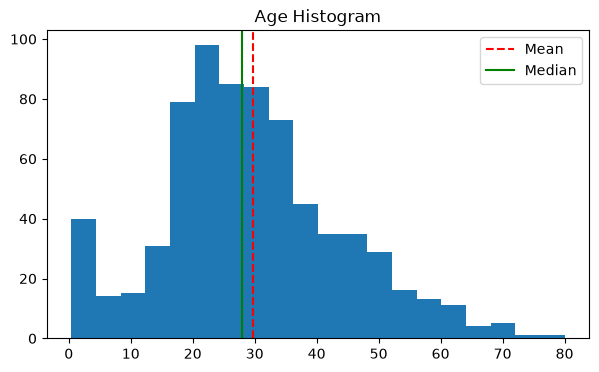

C:\Users\anits-csm\AppData\Local\Temp\ipykernel_20088\4294594933.py:60: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data, vert=False)


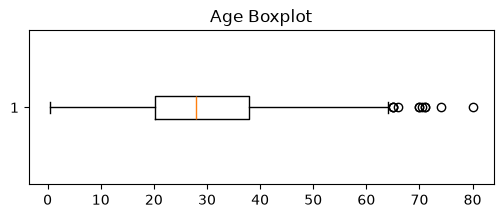


Statistics After Removing Outliers
Mean = 29.07207681365576
Median = 28.0
Variance = 188.4711002391055
Standard Deviation = 13.728477710187153

Column: Fare
Mean = 32.204207968574636
Median = 14.4542
Mode = [8.05]
Variance = 2469.436845743116
Standard Deviation = 49.6934285971809

Quartiles
Q1 = 7.9104
Q2 = 14.4542
Q3 = 31.0
IQR = 23.0896

Number of Outliers = 116


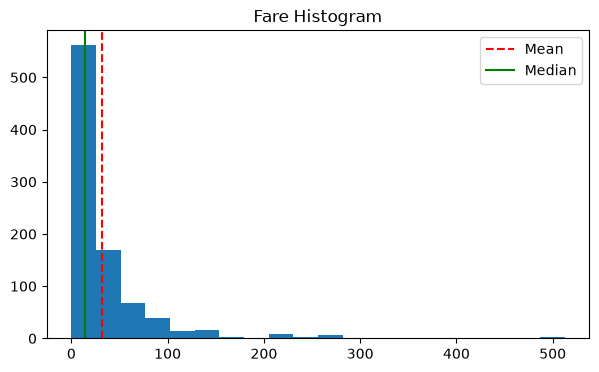

C:\Users\anits-csm\AppData\Local\Temp\ipykernel_20088\4294594933.py:60: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data, vert=False)


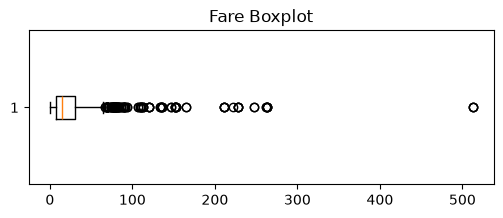


Statistics After Removing Outliers
Mean = 17.82209070967742
Median = 13.0
Variance = 184.36440187474562
Standard Deviation = 13.578085353787758


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# Function to compute descriptive statistics
# ------------------------------------------
def descriptive_statistics(df, column):

    print("\n========================================")
    print("Column:", column)
    print("========================================")

    data = df[column].dropna()

    mean = data.mean()
    median = data.median()
    mode = data.mode().tolist()
    variance = data.var()
    std = data.std()

    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    print("Mean =", mean)
    print("Median =", median)
    print("Mode =", mode)
    print("Variance =", variance)
    print("Standard Deviation =", std)

    print("\nQuartiles")
    print("Q1 =", q1)
    print("Q2 =", q2)
    print("Q3 =", q3)

    print("IQR =", iqr)

    # Outlier detection
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[(data < lower) | (data > upper)]

    print("\nNumber of Outliers =", len(outliers))

    # Histogram
    plt.figure(figsize=(7,4))
    plt.hist(data, bins=20)
    plt.axvline(mean, color='red', linestyle='--', label='Mean')
    plt.axvline(median, color='green', linestyle='-', label='Median')
    plt.title(column + " Histogram")
    plt.legend()
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2))
    plt.boxplot(data, vert=False)
    plt.title(column + " Boxplot")
    plt.show()

    # Remove Outliers
    cleaned = data[(data >= lower) & (data <= upper)]            

    print("\nStatistics After Removing Outliers")

    print("Mean =", cleaned.mean())
    print("Median =", cleaned.median())
    print("Variance =", cleaned.var())
    print("Standard Deviation =", cleaned.std())

# ------------------------------------------
# Dataset 1 : Iris
# ------------------------------------------

iris = pd.read_csv(
    "iris.csv",
    header=None,
    names=["SepalLength","SepalWidth","PetalLength","PetalWidth","Species"]
)

print("IRIS DATASET")
print(iris.head())

print("\nInformation")
print(iris.info())

print("\nSummary")
print(iris.describe())

descriptive_statistics(iris, "PetalLength")

# ------------------------------------------
# Dataset 2 : Titanic
# ------------------------------------------

titanic = pd.read_csv("train.csv")

print("\n\nTITANIC DATASET")
print(titanic.head())

print("\nInformation")
print(titanic.info())

print("\nSummary")
print(titanic.describe())

descriptive_statistics(titanic, "Age")
descriptive_statistics(titanic, "Fare")